In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
from scipy.spatial import KDTree
from collections import deque
import heapq

from geo import topography
from geo import hydrology
from geo import adjacency
from geo import climate
from geo import ecology
from geo import helpers

SEED = 18192601
#SEED = 19960326
random.seed(SEED)
np.random.seed(SEED)

HEIGHT = 720
WIDTH = 1080
N_SEEDS = 10000
N_CONTINENTS = 19
MAX_CONVERGENT = 50
MIN_DIVERGENT = -30


# Cell Generation

In [15]:
def plot_voronoi(points, vor: Voronoi):
    fig, ax = plt.subplots(figsize=(8,8))

    for i, point in enumerate(points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]

        if -1 in region or len(region) == 0:
            continue

        polygon = [vor.vertices[j] for j in region]
        polygon = np.array(polygon)

        ax.fill(*polygon.T, alpha=0.3)

    ax.plot(points[:,0], points[:,1], 'ko', markersize=.5)
    for rigde_vertices in vor.ridge_vertices:
        if -1 in rigde_vertices:
            continue
        v0, v1 = vor.vertices[rigde_vertices]
        ax.plot([v0[0], v1[0]], [v0[1], v1[1]], 'k-')
    
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_title("Voronoi Diagram: Cells + Edges + Seeds")
    plt.show()

# Base cell adjacency graph

In [16]:
def plot_continents(continent_labels, points, vor: Voronoi):
    fig, ax = plt.subplots(figsize=(10,10))

    # assign random colors per continent
    continent_colors = {}
    for label in set(continent_labels):
        continent_colors[label] = np.random.rand(3,)

    for i, point in enumerate(points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]

        if -1 in region or len(region) == 0:
            continue

        polygon = np.array([vor.vertices[j] for j in region if j != -1])
        ax.fill(*polygon.T, color=continent_colors[continent_labels[i]], alpha=0.4)

    # draw edges
    for ridge_vertices in vor.ridge_vertices:
        if -1 in ridge_vertices:
            continue
        v0, v1 = vor.vertices[ridge_vertices]
        ax.plot([v0[0], v1[0]], [v0[1], v1[1]], 'k-', linewidth=0.5)

    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_title("Voronoi Cells Grouped Into Continents")
    plt.show()

In [17]:
def plot_height_map(points, vor, elevations):
    fig, ax = plt.subplots(figsize=(10,10))
    for i, point in enumerate(points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        polygon = np.array([vor.vertices[j] for j in region if j != -1])
        ax.fill(*polygon.T, color=plt.cm.terrain((elevations[i] - elevations.min()) /
                                                 (elevations.max() - elevations.min())), alpha=0.8)
    ax.plot(points[:,0], points[:,1], 'ko', markersize=.2)
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_title("Tectonic-Inferred Height Map")
    plt.show()

In [18]:
def diffuse_elevation(
    elevation,
    adjacency,
    iterations=20,
    smoothing=0.5,
    noise=0.02,
    seed=SEED
):
    """
    Smooth elevation across neighboring cells.
    """
    rng = random.Random(seed)
    elev = elevation.copy()

    for _ in range(iterations):
        new_elev = elev.copy()

        for cell, neighbors in adjacency.items():
            if not neighbors:
                continue

            neighbor_avg = sum(elev[n] for n in neighbors) / len(neighbors)
            jitter = rng.uniform(-noise, noise)

            new_elev[cell] = (
                (1 - smoothing) * elev[cell]
                + smoothing * neighbor_avg
                + jitter
            )

        elev = new_elev

    return elev

In [19]:
def resolveColorMap(elevation, elevations, sea_level, cmap=plt.cm.terrain, sea_max=.175, land_min=.25):
    if elevation > sea_level:
        emax = elevations.max()
        height = elevation - sea_level
        max_height = emax - sea_level

        t = height / max_height
        t = min(t, 1)

        return cmap(land_min + t * (1 - land_min))
    else:
        emin = elevations.min()
        depth = sea_level - elevation
        max_depth = sea_level - emin

        t = depth / max_depth
        t = min(t, 1)

        return cmap(sea_max * (1 - t))

def plot_land_and_sea(points, vor, elevations, sea_level):
    fig, ax = plt.subplots(figsize=(10,10))
    for i, point in enumerate(points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        polygon = np.array([vor.vertices[j] for j in region if j != -1])
        color = resolveColorMap(elevations[i], elevations, sea_level)
        ax.fill(*polygon.T, color=color, alpha=0.8)
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_title("Tectonic-Inferred Height Map")
    plt.show()

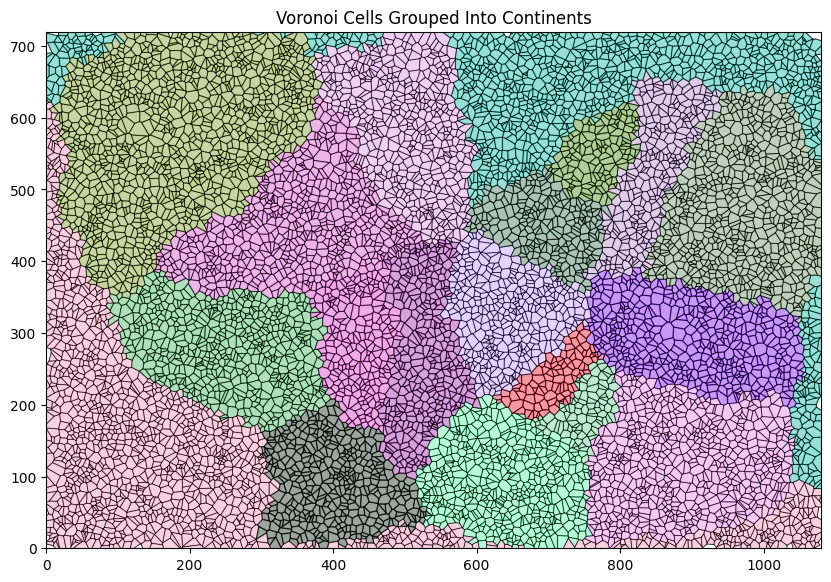

In [20]:
points, vor = topography.generate_voronoi_cells(WIDTH, HEIGHT, N_SEEDS)
adj_graph = adjacency.build_adjacency(points, vor.ridge_points)
valid_indices, _ = helpers.get_inset_seeds(points, WIDTH, HEIGHT)
continent_labels = topography.classify_cells(adj_graph, N_CONTINENTS, valid_indices=valid_indices)
plot_continents(continent_labels, points, vor)
vectors = topography.assign_movement_vectors(continent_labels)
elevations = topography.infer_elevation(points, vor, continent_labels, vectors)

In [21]:
def build_landmass_adjancency_graph(points, vor: Voronoi, landmass_labels):
    adjacency = {i: set() for i in range(len(points))}
    for a, b, in vor.ridge_points:
        if landmass_labels[a] == landmass_labels[b]:
            adjacency[a].add(b)
            adjacency[b].add(a)

    return adjacency

def build_land_adjancency_graph(points, vor: Voronoi, elevations, sea_level):
    adjacency = {i: set() for i in range(len(points))}
    for a, b, in vor.ridge_points:
        if elevations[a] > sea_level and elevations[b] > sea_level:
            adjacency[a].add(b)
            adjacency[b].add(a)

    return adjacency

In [22]:
def get_closest_to_edge(x: float, y:float, max_x, max_y):
    x_coef = min(x, max_x-x) / max_x
    y_coef = min(y, max_y-y) / max_y

    if x_coef < y_coef:
        return 'x', min(x, max_x-x)
    else:
        return 'y', min(y, max_y-y)
    
def compute_falloff_deprecated(points, width=WIDTH, height=HEIGHT, margin=.15, strength=2, noise=.05):
    falloff = np.ones(len(points))
    for idx, point in enumerate(points):
        x, y = point
        min, M = get_closest_to_edge(x, y, width, height) 
        if M > margin:
            continue
        t = helpers.clamp(M / margin, 0, 1)
        falloff[idx] = t ** strength * random.uniform(0, noise ** 2)
    return falloff

def compute_falloff(points, width, height, strength=2.0, margin=.15, mode=None):
    _, affected_cells = helpers.get_inset_seeds(points, width, height, margin)
    effect_points = points[affected_cells]
    max_dist_x = width * margin
    max_dist_y = height * margin

    falloff = np.ones(len(points))
    dists = np.zeros(len(points))
    factor = np.zeros(len(points))
    for i, idx in enumerate(affected_cells):
        x, y = effect_points[i]
        axis, dist = get_closest_to_edge(x, y, width, height)
        if axis == 'x':
            k = (max_dist_x - dist)/max_dist_x
            dists[idx] = (max_dist_x - dist)
        else:
            k = (max_dist_y - dist)/max_dist_y
            dists[idx] = (max_dist_y - dist)
        
        factor[idx] = k

    falloff -= factor ** strength

    if mode == "debug":
        return falloff, factor, dists
    else:
        return falloff

def apply_falloff(elevations, falloff):
    new = elevations.copy()
    new *= falloff
    return new



In [23]:
def compute_cell_distance(elevated_cells_by_landmass, adjacency) -> tuple[dict, dict]:
    distance = {}
    sources = {}
    queue = deque()

    for landmass, cells in elevated_cells_by_landmass.items():
        queue.clear()
        for cell in cells:
            distance[cell] = 0
            queue.append(cell)

        while queue:
            current = queue.popleft()
            current_distance = distance[current]

            for neighbor in adjacency[current]:
                if not neighbor in distance:
                    distance[neighbor] = current_distance + 1
                    if current in sources:
                        sources[neighbor] = sources[current]
                    else:
                        sources[neighbor] = current
                    queue.append(neighbor)
        
    return distance, sources

In [24]:
landmass_adjacency = build_landmass_adjancency_graph(points, vor, continent_labels)

In [25]:
def propagate_elevations_deprecated(elevations, continent_labels, adjacency_by_landmass, decay=.05, noise=.25):
    source = elevations.copy()
    elevated_cells = [np.int32(idx) for idx, cell in enumerate(elevations) if cell != 0]

    elevated_cells_by_landmass = {}
    for idx, label in enumerate(continent_labels):
        if label in elevated_cells_by_landmass and elevations[idx] != 0:
            elevated_cells_by_landmass[label] = np.append(elevated_cells_by_landmass[label], np.int32(idx))
        elif elevations[idx] != 0:
            elevated_cells_by_landmass[label] = np.array([], dtype=np.int32)
            elevated_cells_by_landmass[label] = np.append(elevated_cells_by_landmass[label], np.int32(idx))

    distances, elevated_affected_cells = compute_cell_distance(elevated_cells_by_landmass, adjacency_by_landmass)

    for affected_cell, elevated_cell in elevated_affected_cells.items():
        elevation = elevations[elevated_cell]

        if elevation >= 0:
            effect = elevation * decay ** distances[affected_cell]
            source[affected_cell] = effect
        else:
            effect = elevation * decay ** (distances[affected_cell] ** 5)
            source[affected_cell] = effect

    for cell in elevated_cells:
        source[cell] = source[cell] * (decay + random.uniform(0, noise))

    return source

In [26]:
def diffuse_field(scalar_field: np.array, adjacency_graph, iterations=5):
    new = scalar_field.copy()

    for i in range(iterations):    
        for idx, scalar in enumerate(new):
            neighbors = [new[n] for n in adjacency_graph[idx]]
            local_sum = scalar + sum(neighbors)
            cells = 1 + len(neighbors)
            new[idx] = local_sum / cells
            for neighbor in adjacency_graph[idx]:
                new[neighbor] = local_sum / cells

    return new

In [27]:
falloff, factors, dists = compute_falloff(points, WIDTH, HEIGHT, margin=.05, strength=.15, mode="debug")

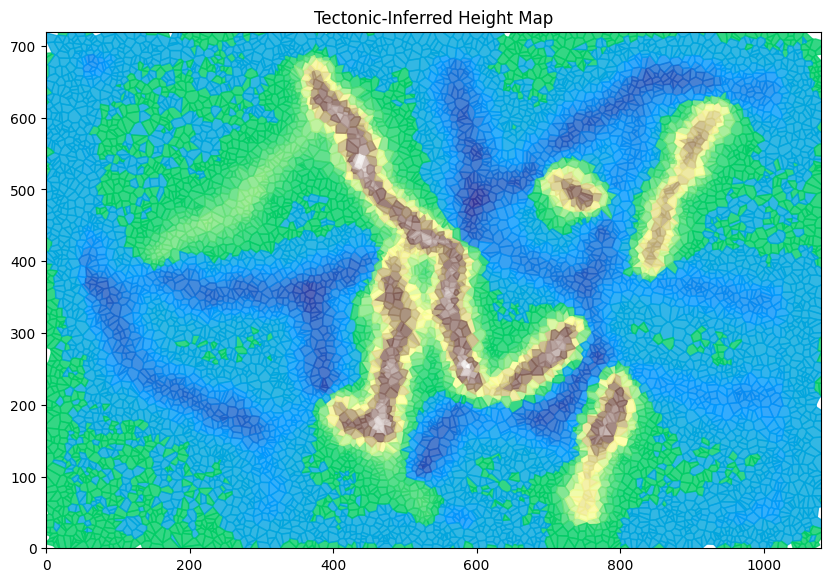

In [29]:
fo_elevations = apply_falloff(elevations, falloff)
pro_fo_elevations = topography.propagate_elevations(fo_elevations, continent_labels, landmass_adjacency, decay=.35)
diff_pro_fo_elevations = diffuse_elevation(pro_fo_elevations, adj_graph, iterations=8, noise=.1, seed=SEED)
fo_diff_pro_fo_elevations = apply_falloff(diff_pro_fo_elevations, falloff)
land, sea_level = topography.apply_sea_level(fo_diff_pro_fo_elevations, 60)
plot_land_and_sea(points, vor, fo_diff_pro_fo_elevations, sea_level)
final_elevations = fo_diff_pro_fo_elevations

In [30]:
def describe_elevation_array(elevations):
    print(f"""\nMin: {elevations.min()} \nMax: {elevations.max()}\nMean: {elevations.mean()}""")

In [123]:
# import json
# def serialize_data(elevations, points, sea_level):
#     root = {
#         "elevation_data": [],
#         "sea_level": sea_level
#         }
#     for idx, elevation in enumerate(elevations):
#         root["elevation_data"].append({
#             "id": idx,
#             "coordinates": points[idx].tolist(),
#             "elevation": elevation
#         })

#     data = json.dumps(root)

#     with open("map_data.json", "w") as outfile:
#         json.dump(data, outfile, indent=4, sort_keys=False)


# serialize_data(fo_elevations, points, sea_level=sea_level)


In [31]:
def generate_rainfall_mask(points):
    rainfall = np.zeros(len(points))
    for idx, value in enumerate(rainfall):
        rainfall[idx] = random.uniform(0, 1)

    return rainfall

def plot_rainfall(points, vor, rainfall):
    fig, ax = plt.subplots(figsize=(10,10))
    for i, point in enumerate(points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        polygon = np.array([vor.vertices[j] for j in region if j != -1])
        color = plt.cm.Blues(rainfall[i])
        ax.fill(*polygon.T, color=color, alpha=0.8)
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_title("Rainfall Map")
    plt.show()

In [32]:
rainfall = generate_rainfall_mask(points)
diff_rainfall = diffuse_elevation(rainfall, adj_graph)

# Drainage

Base cases

neighbor elevation is below sea level -> drains to sea
neighbor elevation is above sea level and lower than current cell -> drain inland
 

# Drainage flow modelling

slope is the difference between the current cell's elevation and the neighbor with the lowest elevation
absorption is a function of a base absorption argument * 1/slope
outflow is the result of the "water" left after absoption + the sum of all inflows from tributaries upstream


In [33]:
drainage_array, absorption_data = hydrology.generate_drainage_data(final_elevations, adj_graph, sea_level)

In [34]:

watersheds = hydrology.label_watersheds(drainage_array)

In [36]:
flow_graph = hydrology.compute_flow_volume(drainage_array, rainfall, absorption_data)

ValueError: maximum supported dimension for an ndarray is currently 64, found 10000

In [ ]:


drainage_segments = hydrology.build_drainage_segments(points, vor, drainage_array)

# Basin identification

Based on the drainage graph there are 2 types of sinks. Inland sinks (-1) that in topology are called endorheic basins, and sea adjacent sinks (-2), which are the model for river deltas.

To identify a basin inland sinks need to be singled out.

Invariants:
A basin is a collection of cells that are below the maximum water level before water escapes the depression.
A saddle is the lowest point of a rim that marks the highest level ther water can reach before escaping
An exit is a cell that is connected to a drainage system that reaches the sea.



A cell is part of a basin if its elevation is below the current maximum water level.
A saddle can be a cell, or the connection between cells.
An exit necesarrily is a cell that is connected to a sea reaching drainage system

In [133]:
land_adjacency_graph = build_land_adjancency_graph(points, vor, final_elevations, sea_level)

In [ ]:
new_basin_labels, basin_membership = hydrology.label_basins(drainage_array, land_adjacency_graph, final_elevations, watersheds)

In [ ]:
temperatures, normalized_temperatures = climate.infer_temperatures(points, final_elevations, sea_level, elevation_effect_strength=.47)

In [136]:
tropics = [.25, .5, .75]


def label_tropic_cells(points, tropic_step: float, height):
    labels = np.full(len(points), [-1], dtype=int)
    step = tropic_step * height
    for idx, centroid in enumerate(points):
        labels[idx] = centroid[1] // step

    return labels

tropic_labels = label_tropic_cells(points, .25, HEIGHT)

def compute_tropics(tropic_steps, height):
    tropics = []
    for i, step in enumerate(tropic_steps):
        if i == 0:
            tropics.append(height * step)
        else:
            tropics.append(height * step + tropics[i-1])

    return tropics

def label_t_cells(points, height, tropic_steps=[.05, .2, .25, .25, .2, .05]):
    labels = np.full(len(points), [-1], dtype=int)
    tropics = compute_tropics(tropic_steps, height)

    for idx, centroid in enumerate(points):
        pass

test = compute_tropics(tropic_steps=[.05, .2, .25, .25, .2, .05], height=HEIGHT)

In [ ]:


moisture = climate.infer_moisture(final_elevations, normalized_temperatures, sea_level)

In [162]:
normalized_temperatures[2257]

np.float16(0.0237)

In [ ]:
np.seterr(divide='warn', invalid='warn', over='warn')
vectors = [[1, 1],
           [-1, 1],
           [-1, -1],
           [1, -1]]

climate = climate.infer_precipitation(points, normalized_temperatures, moisture, adj_graph, tropic_labels, vectors, evaporation_rate=.08)

-0.0019549942
-0.00015759231
-0.0001572038
-0.00015720238
-0.00015720272
-0.00015720297
-0.00015720313
-0.00015720325
-0.00015720334
-0.00015720337
-0.00015720341
-0.00015720344
-0.00015720345
-0.00015720347
-0.00015720347
-0.00015720347
-0.00015720347
-0.00015720347
-0.00015720348
-0.00015720347
-0.00015720347
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348
-0.00015720348


In [140]:
print(np.where(np.isnan(climate["moisture"])))
print(np.where(np.isnan(climate["precipitation"])))
print(np.where(moisture < 0))

(array([], dtype=int64),)
(array([], dtype=int64),)
(array([], dtype=int64),)


In [141]:
print(temperatures[2257])

-36.28


In [ ]:


evaporation = hydrology.compute_evaporation(normalized_temperatures, climate["moisture"])

In [143]:
diffused_precipitation = diffuse_field(climate["precipitation"], adj_graph, iterations=5)

In [144]:
# import plotly.graph_objects as go
# import plotly.io as pio
# pio.renderers.default = 'browser'

# def plotly_voronoi(points, vor, width, height):
#     fig = go.Figure()

#     for idx, point in enumerate(points):
#         region_index = vor.point_region[idx]
#         region = vor.regions[region_index]

#         if -1 in region or len(region) == 0:
#             continue
        
#         polygon = np.array([vor.vertices[j] for j in region])

#         x = polygon[:, 0].tolist() + [polygon[0, 0]]
#         y = polygon[:, 1].tolist() + [polygon[0, 1]]

#         clamped_x = [clamp(i, 0, width) for i in x]
#         clamped_y = [clamp(i, 0, height) for i in y]

#         fig.add_trace(
#             go.Scatter(
#                 x=clamped_x,
#                 y=clamped_y,
#                 mode="lines",
#                 fill="toself",
#                 line=dict(color="black", width=0.5),
#                 fillcolor="rgba(200,200,200,0.6)",
#                 hoverinfo="none"
#             )
#         )
#     fig.update_layout(
#         xaxis=dict(scaleanchor="y"),
#         yaxis=dict(scaleratio=1),
#         showlegend=False
#     )

#     return fig

In [ ]:
def scale_elevations(elevations, sea_level, percentile=.95, percentile_map=8800):
    zero_sea_level_elevations = elevations + (-1 * sea_level)
    k = percentile_map / np.quantile(elevations, [percentile])
    elevations_m = zero_sea_level_elevations * k
    return elevations_m

elevations_m = scale_elevations(final_elevations, sea_level)

def scale_precipitation(precipitation, percentile=.95, percentile_map=2500):
    k = percentile_map / np.quantile(diffused_precipitation, [percentile])
    precipitation_mm = precipitation * k
    return precipitation_mm

precipitation_mm = scale_precipitation(diffused_precipitation)

In [146]:
def scale_elevations_exponential(elevations, sea_level, percentile=.95, percentile_map=8800):
    zero_sea_level_elevations = elevations + (-1 * sea_level)
    k = percentile_map / np.quantile(elevations, [percentile])
    elevations_m = zero_sea_level_elevations * k
    return elevations_m

elevations_m = scale_elevations_exponential(final_elevations, sea_level)

In [ ]:
biome_colors = {
    1: [225, 180, 114, 1],
    2: [203, 182, 107, 1],
    3: [144, 120, 84, 1],
    4: [165, 186, 94, 1],
    5: [126, 189, 81, 1],
    6: [40, 164, 46, 1],
    7: [48, 196, 55, 1],
    8: [31, 132, 36, 1],
    9: [121, 167, 70, 1],
    10: [51, 96, 53, 1],
    11: [184, 217, 185, 1],
    12: [216, 228, 224, 1],
    13: [179, 186, 147, 1],
    14: [123, 142, 106, 1],
    15: [80, 103, 60, 1]
}

def biome_rgba(biome_colors):
    rgba = {}
    for id, color in biome_colors.items():
        r, g, b, a = color
        rgba[id] = (r/255, g/255, b/255, a)

    return rgba

biome_mapping = {
    0: {"name": "ocean", "features" : {}},
    1: {"name": "desert", "features": {"t": 32, "p": 100, "t_spread": 7, "p_spread": 200}},
    2: {"name": "savannah", "features": {"t": 28, "p": 600, "t_spread": 6, "p_spread": 300}},
    3: {"name": "cold desert", "features": {"t": 5, "p": 200, "t_spread": 5, "p_spread": 200}},
    4: {"name": "steppe", "features": {"t": 8, "p": 500, "t_spread": 5, "p_spread": 200}},
    5: {"name": "grassland", "features": {"t": 18, "p": 700, "t_spread": 6, "p_spread": 200}},
    6: {"name": "rainforest", "features": {"t": 27, "p": 3000, "t_spread": 5, "p_spread": 600}},
    7: {"name": "temperate rainforest", "features": {"t": 15, "p": 3000, "t_spread": 5, "p_spread": 600}},
    8: {"name": "temperate deciduous forest", "features": {"t": 12, "p": 1500, "t_spread": 6, "p_spread": 400}},
    9: {"name": "temperate forest", "features": {"t": 18, "p": 600, "t_spread": 6, "p_spread": 250}},
    10: {"name": "taiga", "features": {"t": 3, "p": 600, "t_spread": 5, "p_spread": 250}},
    11: {"name": "tundra", "features": {"t": -5, "p": 400, "t_spread": 5, "p_spread": 200}},
    12: {"name": "glacier", "features": {"t": -10, "p": 800, "t_spread": 4, "p_spread": 400}},
}

biome_subtype_mapping = {
    13: {"name": "bog", "features" : {"t": 5, "t_spread": 5, "abs": 3.5, "abs_spread": .5}},
    14: {"name": "marsh", "features" : {"t": 15, "t_spread": 8, "abs": 3.5, "abs_spread": .5}},
    15: {"name": "wetland", "features" : {"t": 25, "t_spread": 10, "abs": 3.5, "abs_spread": .5}}
}

def unify_biome_maps(*biome_mappings):
    new_map = {}
    for map in biome_mappings:
        for id, data in map.items():
            new_map[id] = data["name"]

    return new_map

biome_names = unify_biome_maps(biome_mapping, biome_subtype_mapping)
biome_rgba = biomes.biome_rgba(biome_colors)

In [ ]:

biomes = biomes.infer_biomes(elevations_m, temperatures, precipitation_mm, biome_mapping)


In [ ]:
flow_graph_mm = hydrology.compute_flow_volume(drainage_array, precipitation_mm, absorption_data, evaporation)
drainage_segments = hydrology.build_drainage_segments(points, vor, drainage_array)

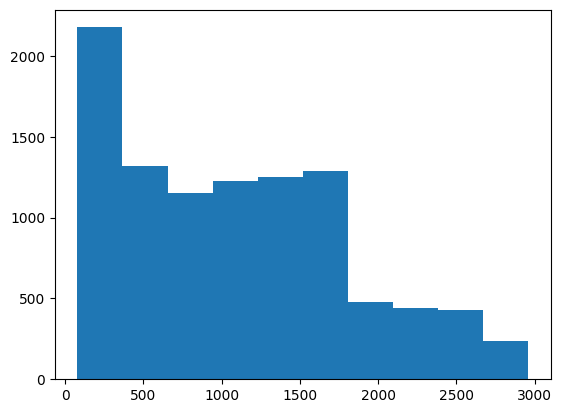

In [153]:
x = (precipitation_mm)
fig, ax = plt.subplots()
ax.hist(x, range=(x.min(), x.max()))
plt.show()

In [ ]:


hydrology = hydrology.infer_hydrology(elevations_m, flow_graph_mm, new_basin_labels, drainage_array)

In [155]:
#print(np.arange(0, WIDTH))
#print(np.arange(0, HEIGHT))
x, y  = np.meshgrid(np.arange(0, HEIGHT), np.arange(0, WIDTH), indexing="xy")
matrix = np.stack([x, y], axis=-1)
flat = matrix.reshape(-1, 2)

In [ ]:
from matplotlib.collections import PolyCollection, LineCollection
from types import SimpleNamespace

def build_voronoi_geometry(points, vor):
    polygons = []
    indices = []

    for i, points in enumerate(points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        polygon = np.array([vor.vertices[j] for j in region if j != -1])
        polygons.append(polygon)
        indices.append(i)

    return polygons, indices

def terrain_overlay(polygons, indices, elevations, sea_level, cm=plt.cm.terrain, alpha=0.8, sea_max=.175, land_min=.25):
    color_map = np.full(len(indices), [-1], dtype=np.float16)
    
    for i, idx in enumerate(indices):
        if elevations[idx] > sea_level:
            emax = elevations.max()
            height = elevations[idx] - sea_level
            max_height = emax - sea_level

            t = height / max_height
            t = (min(t, 1))

            color_map[i] = land_min + t * (1 - land_min)
        else:
            emin = elevations.min()
            depth = sea_level - elevations[idx]
            max_depth = sea_level - emin
            
            t = depth / max_depth
            t = min(t, 1)

            color_map[i] = (sea_max * (1 - t))
    
    colors = cm(color_map)

    collection = PolyCollection(
        polygons,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
    )

    collection.set_facecolor(colors)
    return collection

def drainage_overlay(polygons, indices, drainage_segments):
    segments = list(drainage_segments.values())
        
    collection = LineCollection(
        segments,
        color="deepskyblue",
        linewidth=.8,
        zorder=9
    )

    return collection

def drainage_volume_overlay(polygons, indices, drainage_segments, flow_volumes, width_multiplier=1):
    segments = list(drainage_segments.values())
    linewidths = []
    vmin = flow_volumes.min()
    vmax = flow_volumes.max()

    for idx, segment in drainage_segments.items():
        volume = flow_volumes[idx]
        t = (volume - vmin)/(vmax - vmin)
        linewidths.append(t * width_multiplier)
    
    collection = LineCollection(
        segments,
        color="deepskyblue",
        linewidths=linewidths,
        zorder=8
    )

    return collection

def watershed_overlay(polygons, indices, watersheds, cm=plt.cm.turbo, alpha=.2):
    poly_subset = []
    color_map = []
    step = 1 / (len(np.unique(watersheds)) - 1)
    watersheds_colors = { label: i * step for i, label in enumerate(np.unique(watersheds)) if label != -1 }

    for i, idx in enumerate(indices):
        if watersheds[idx] != -1 and idx not in watersheds_colors.keys():
            color_map.append(watersheds_colors[watersheds[idx]])
            poly_subset.append(polygons[i])
            
    colors = cm(color_map)

    collection = PolyCollection(
        poly_subset,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=2
    )

    collection.set_facecolor(colors)
    return collection
        

def highlight_cell_overlay(polygons, indices, highlights: list, color: float, cm=plt.cm.hsv, alpha=.8):
    poly_subset = []
    color_map = []

    highlights_set = set(highlights)

    for i, idx in enumerate(indices):
        if idx in highlights_set:
            color_map.append(color)
            poly_subset.append(polygons[i])

    colors = cm(color_map)

    collection = PolyCollection(
        poly_subset,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=5
    )
    
    collection.set_facecolor(colors)
    return collection

def basins_overlay(polygons, indices, basin_labels, cm=plt.cm.turbo, alpha=.8):
    poly_subset = []
    color_map = []

    step = 1 / len(np.unique(basin_labels))
    basin_color_map = {label: i * step for i, label in enumerate(np.unique(basin_labels))}

    for i, idx in enumerate(indices):
        if basin_labels[idx] == -1:
            continue
        else:
            poly_subset.append(polygons[i])
            color_map.append(basin_color_map[basin_labels[idx]])
    
    colors = cm(color_map)

    collection = PolyCollection(
        poly_subset,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=3
    )

    collection.set_facecolor(colors)
    return collection

def temperature_overlay(polygons, indices, temperatures, cm=plt.cm.coolwarm, alpha=.2):
    color_map = np.full(len(indices), [-1], dtype=np.float16)

    for i, idx in enumerate(indices):
        color_map[i] = .5 + (temperatures[idx] / 50)

    colors = cm(color_map)

    collection = PolyCollection(
        polygons,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=3
    )

    collection.set_facecolor(colors)
    return collection

def moisture_overlay(polygons, indices, moisture, cm=plt.cm.Blues, alpha=.25):
    color_map = np.full(len(indices), [-1], dtype=np.float16)

    for i, idx in enumerate(indices):
        color_map[i] = moisture[idx]

    colors = cm(color_map)

    collection = PolyCollection(
        polygons,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=3
    )

    collection.set_facecolor(colors)
    return collection

def tropic_overlay(polygons, indices, width, height, tropics=[.25, .5, .75]):
    lines = []
    # for tropic in tropics:
    #     line = ax.hlines(height * tropic, xmin=0, xmax=width, colors='k')
    #     artists.append(line)

    return 

def precipitation_overlay(polygons, indices, precipitation, cm=plt.cm.YlGnBu, alpha=.25):
    color_map = np.full(len(indices), [-1], dtype=np.float32)
    vmax = 1
    vmin = precipitation.min()

    for i, idx in enumerate(indices):
        color_map[i] = (precipitation[idx] - vmin) / (vmax - vmin)

    colors = cm(color_map)
    
    collection = PolyCollection(
        polygons,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=4
    )
    
    collection.set_facecolor(colors)
    return collection

def biome_overlay(polygons, indices, biomes, cm, alpha=.5):
    poly_subset = []
    color_map = []

    for i, idx in enumerate(indices):
        if biomes[idx] <= 0: #excludes ocean & error indices
            continue
        
        poly_subset.append(polygons[i])
        color_map.append(cm[biomes[idx]])

    colors = color_map

    collection = PolyCollection(
        poly_subset,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=4
    )

    collection.set_facecolor(colors)
    return collection

def lake_overlay(polygons, indices, lakes, cm=plt.cm.Blues, alpha=.5):
    index_map = { idx: i for i, idx in enumerate(indices) }
    poly_subset = []
    color_map = []
    for lake in lakes.values():
        for idx in lake:
            i = index_map.get(idx)
            if i is not None:
                poly_subset.append(polygons[i])
                color_map.append((0.0, 0.7372549019607844, 1.0, 1.0))

    collection = PolyCollection(
        poly_subset,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        alpha=alpha,
        zorder=9
    )

    collection.set_facecolor(color_map)
    return collection

def plot_world(points, vor, overlays: list, name: str="", dpi=300):
    fig, ax = plt.subplots(figsize=(10, 10), dpi=dpi)
    
    polygons, indices = build_voronoi_geometry(points, vor)

    layers = {}
    layer_visible = {}

    for layer_name, visible_toggle, overlay_fn, kwargs in overlays:
        collection = overlay_fn(polygons, indices, **kwargs)
        ax.add_collection(collection)
        layers[layer_name] = collection
        layer_visible[layer_name] = visible_toggle
    
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_title(name)
    
    return fig, ax , layers, layer_visible

0

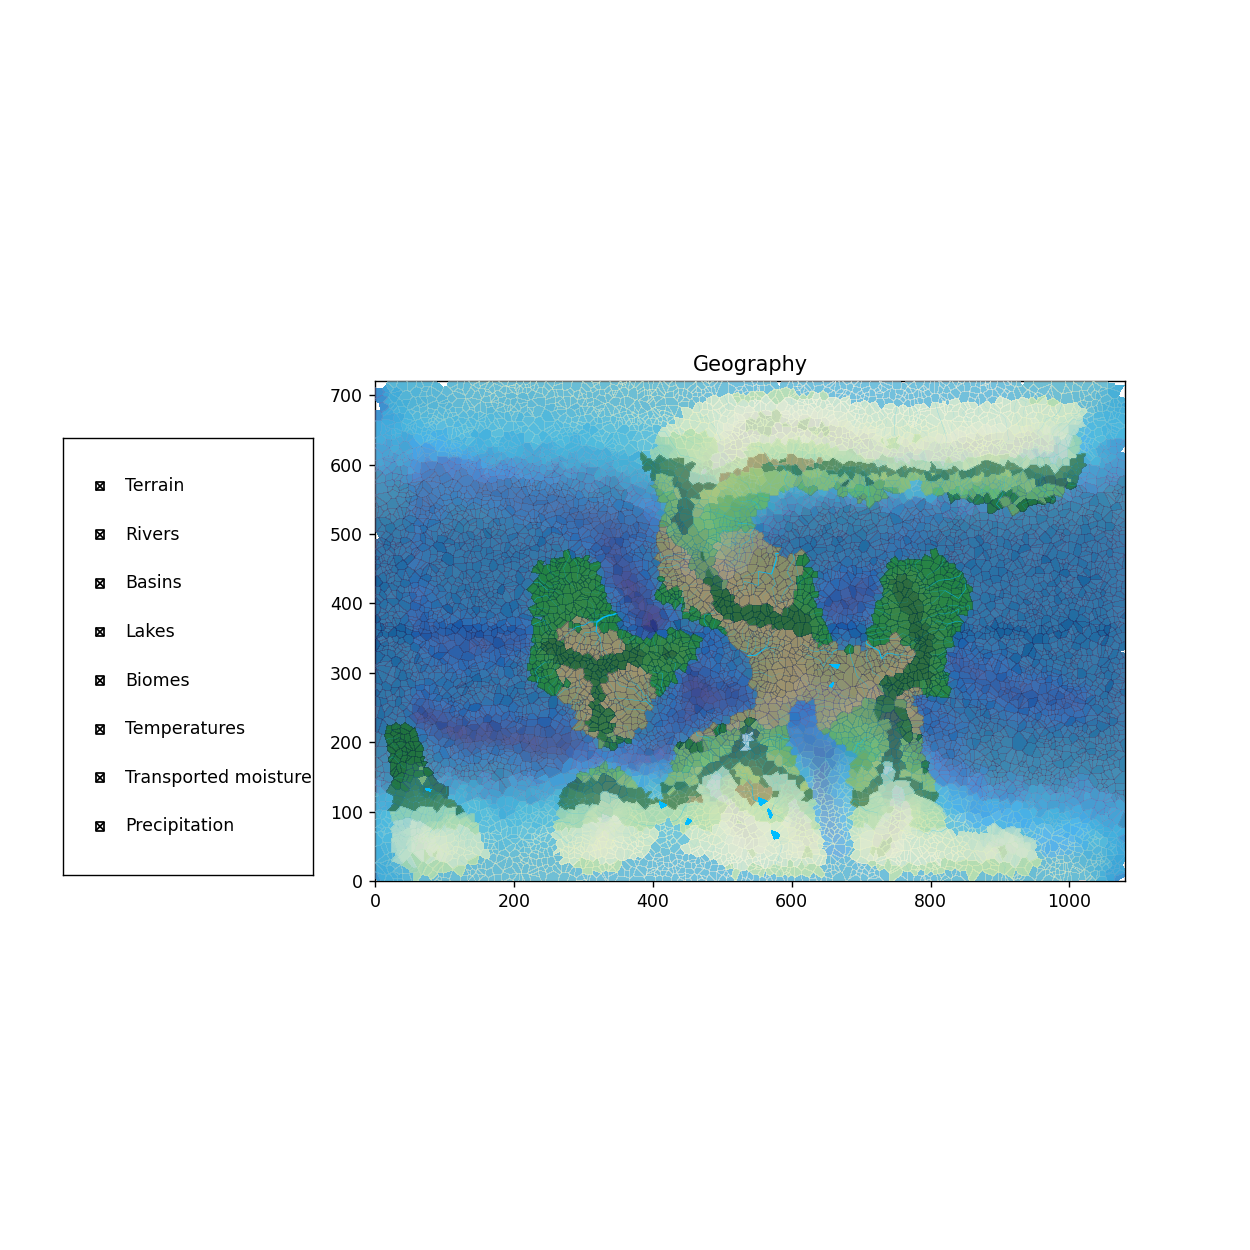

In [157]:
%matplotlib widget
from matplotlib.widgets import CheckButtons

tree = KDTree(points)

def format_coords(x, y):
    dist, idx = tree.query([x, y])

    elev = final_elevations[idx]
    temp = temperatures[idx]
    flow = flow_graph_mm[idx]
    prec = precipitation_mm[idx]
    bio = biome_names[biomes[idx]] if biomes[idx] != -1 else "no biome"
    
    return (
        f"x={x:.1f}, y={y:.1f} | "  
        f"cell={idx} | "
        f"elev={elev:.2f} | "
        f"temp={temp:.2f} | "
        f"flow={flow:2f} | "
        f"precipitation={prec:2f} | "
        f"biomes={bio} | "
    )

def toggle_layer(name):
    layer_visible[name] = not layer_visible[name]
    layers[name].set_visible(layer_visible[name])
    fig.canvas.draw_idle()

def on_click(label):
    toggle_layer(label)

fig, ax, layers, layer_visible = plot_world(
    points,
    vor,
    [
        ("Terrain", True, terrain_overlay,{"elevations": elevations_m, "sea_level": 0}),
        #("Watersheds", True, watershed_overlay, {"watersheds": watersheds, "alpha": .8}),
        #("Drainage", True, drainage_overlay, {"drainage_segments": drainage_segments}),
        #("Drainage Volume", True, drainage_volume_overlay, {"drainage_segments": drainage_segments, "flow_volumes": flow_graph}),
        ("Rivers", True, drainage_volume_overlay, {"drainage_segments": drainage_segments, "flow_volumes": hydrology["rivers"]}),
        #("Basins", True, basins_overlay, {"basin_labels" : new_basin_labels}),
        ("Basins", True, basins_overlay, {"basin_labels" : basin_membership}),
        ("Lakes", True, lake_overlay, {"lakes": hydrology["lakes"], "alpha": 1}),
        ("Biomes", True, biome_overlay, {"biomes": biomes, "cm": biome_rgba, "alpha": .8}),
        ("Temperatures", True, temperature_overlay, {"temperatures": temperatures}),
        #("Highlights", True, highlight_cell_overlay, {"highlights": [90]})
        #("Tropics", True, tropic_overlay, {"width": WIDTH, "height": HEIGHT}),
        ("Transported moisture", True, moisture_overlay, {"moisture": climate["moisture"]}),
        #("Precipitation", True, precipitation_overlay, {"precipitation": precipitation}),
        ("Precipitation", True, precipitation_overlay, {"precipitation": diffused_precipitation}),
    ],
    "Geography", dpi=125)

ax.format_coord = format_coords
labels = list(layers.keys())
states = [layer_visible[l] for l in labels]
fig.subplots_adjust(left=0.3)
rax = plt.axes([0.05, 0.3, 0.2, 0.35])
checks = CheckButtons(rax, labels, states)
checks.on_clicked(on_click)

In [158]:
import math
def river_segments_discrete(drainage_segments):
    pass

In [159]:
def build_coordinates(width, height):
    x, y  = np.meshgrid(np.arange(0, height), np.arange(0, width), indexing="xy")
    return np.stack([x, y], axis=-1).reshape(-1, 2)

def rasterize_map(width, height, points, elevations_m, temperatures_c, precipitation_mm, biomes, flow_graph_mm):
    coords = build_coordinates(width, height)
    coordinates = []
    elevations = []
    temperatures = []
    precipitation = []
    biome = []
    rivers = {}
    lakes = {}

    tree = KDTree(points)
    
    for i, (x, y) in enumerate(coords):
        dist, idx = tree.query([x, y])
        coordinates.append([x, y])
        elevations.append(elevations_m[idx])
        temperatures.append(temperatures_c[idx])
        precipitation.append(precipitation_mm[idx])
        biome.append(biomes[idx])

    return {"coordinates": coordinates, "elevation": elevations, "temperature": temperatures, "precipitation": precipitation, "biomes": biome}

payload = rasterize_map(WIDTH, HEIGHT, points, elevations_m, temperatures, precipitation_mm, biomes, flow_graph_mm)

In [160]:
payload["temperature"][10]

np.float16(-35.28)